In [2]:
import numpy as np
import xarray as xr
import sys
sys.path.append('../')
from xdispersion import RelativeDispersion
from xdispersion import rel_disp
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# Use a serif font globally
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'       # main font for text
mpl.rcParams['mathtext.fontset'] = 'cm'    # math text (e.g., $u_s$)


# Calculate velocity correlation function and anisotropy

Import all data (mean flow and fluctuations). Takes about 10 minutes to compute statistics for 4*2 experiments.

In [3]:

#Save figure or not
save = False



# List of dataset paths (both with mean flow and no mean flow)
files = [
    './data/ExpA/fort.3001.np4000nt6000.nc',
    './data/ExpB/fort.1001.np4000nt5993.nc',
    './data/ExpN/fort.1001.np4000nt6000.nc',
    './data/ExpO/fort.1001.np4000nt6000.nc',    
    './data/ExpA/fort.4001nomean.np4000nt6000.nc',
    './data/ExpB/fort.2001nomean.np4000nt5993.nc',
    './data/ExpN/fort.2001nomean.np4000nt6000.nc',
    './data/ExpO/fort.2001nomean.np4000nt6000.nc'
]

# Open all datasets into a list
drifters_list = [xr.open_dataset(f) for f in files]

lvc_list = [] #lagrangian velocity correlation
rrms_list= [] #rms separation
rzrr_list = [] #ratio zonal to radial separation

for i,ds in enumerate(drifters_list):
    drifters = drifters_list[i]
    rd = RelativeDispersion(drifters, ragged=False, ID='tracer',
                        xpos='x', uvel='ux', time='time',
                        ypos='y', vvel='uy', coord='polar')
    pairs = rd.get_all_pairs()
    origin_pairs = rd.get_original_pairs(pairs, r0=[0.005, 0.01])
    rx, ry, rxy, r, rpb = rd.separation_measures(origin_pairs) # separations of different components
    du, dv, dul, dut, vmi, vmj, uv = rd.velocity_measures(origin_pairs) # velocities of different components
    
    r2   = rel_disp(r, order=2, mean_at='const-t') #pair separation 
    r2x   = rel_disp(rx, order=2, mean_at='const-t') #radial
    r2y   = rel_disp(ry, order=2, mean_at='const-t') #zonal (arclength)

    rrms = np.sqrt(r2) #rms separation
    rrms_list.append(rrms)
    rzrr_list.append(r2y/r2x)

    #Lagrangian velocity correlation
    vmim =(vmi**2).mean('pair') #vmi is velocity magnitude of particle i.
    vmjm =(vmj**2).mean('pair') #vmj velocity magnitude of particle j.
    uvm  =  uv.mean('pair') #uv is inner product of two particle's velocities
    lvc = 2.0 *uvm /(vmim + vmjm) 
    lvc_list.append(lvc)

#lvc_list


/home/dgsl1/miniforge3/envs/xdispersion/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in arccos
  result_data = func(*input_data)
/home/dgsl1/miniforge3/envs/xdispersion/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in arccos
  result_data = func(*input_data)
/home/dgsl1/miniforge3/envs/xdispersion/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in arccos
  result_data = func(*input_data)
/home/dgsl1/miniforge3/envs/xdispersion/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in arccos
  result_data = func(*input_data)


Plot correlation and anisotropy for both on same figure for revised manuscript.

In [4]:
save=True

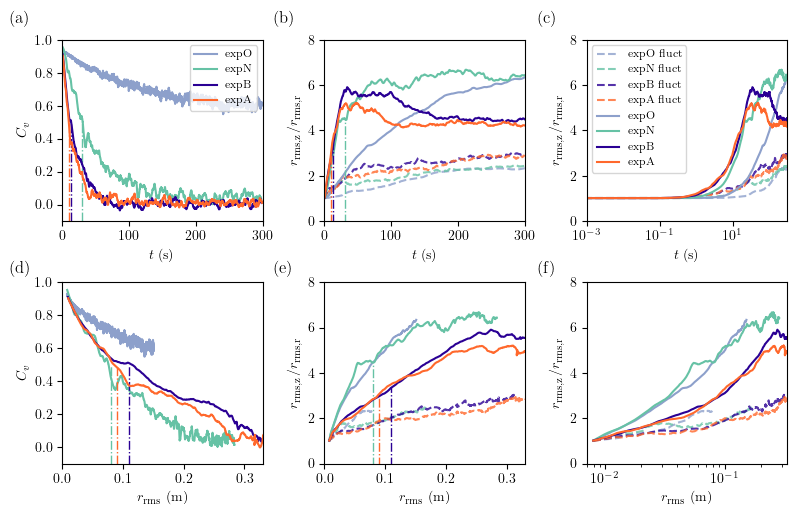

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Labels and styling
# -------------------------
exp_labels = [
    "expA", "expB", "expN", "expO",
    "expA fluct", "expB fluct", "expN fluct", "expO fluct"
]

colors = ['tab:blue','tab:orange','tab:green','tab:red'] * 2
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 4)) * 2
colors = ["#ff682c","#2a0094",'#66c2a5', '#8da0cb'] *2

# Smoothing
lvc_plot_list = [ds.rolling(rtime=30, center=True).mean() for ds in lvc_list]

# -------------------------
# Figure
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(8, 5))

# -------------------------
# Main loop
# -------------------------
for rzrr, lvc, rrms, c, label in zip(
    rzrr_list[::-1],
    lvc_plot_list[::-1],
    rrms_list[::-1],
    colors[::-1],
    exp_labels[::-1]
):

    linest = '-' if 'fluct' not in label else '--'
    alpha = 1.0 if 'fluct' not in label else 0.8

    # ---- Column 1: Cv ----
    if 'fluct' not in label:
        axes[0, 0].plot(lvc.rtime, lvc.values,
                        color=c, linestyle=linest, alpha=alpha, label=label, linewidth=1.5)

        axes[1, 0].plot(rrms, lvc.values,
                    color=c, linestyle=linest, alpha=alpha, linewidth=1.5)
            # Add the reference dashed lines for Cv vs t
        if label == "expA":
            axes[0, 0].plot([10, 10], [-0.1, 0.5], '-.', color=c, linewidth=1)
            axes[1, 0].plot([0.09, 0.09], [-0.1, 0.5], '-.', color=c, linewidth=1)
            axes[0, 1].plot([10, 10], [-0.1, 3], '-.', color=c, linewidth=1)
            axes[1, 1].plot([0.09, 0.09], [-0.1, 3], '-.', color=c, linewidth=1)
        elif label == "expB":
            axes[0, 0].plot([13, 13], [-0.1, 0.5], '-.', color=c, linewidth=1)
            axes[1, 0].plot([0.11, 0.11], [-0.1, 0.5], '-.', color=c, linewidth=1)
            axes[0, 1].plot([13, 13], [-0.1, 3.4], '-.', color=c, linewidth=1)
            axes[1, 1].plot([0.11, 0.11], [-0.1, 3.4], '-.', color=c, linewidth=1)
        elif label == "expN":
            axes[0, 0].plot([30, 30], [-0.1, 0.5], '-.', color=c, linewidth=1)
            axes[1, 0].plot([0.08, 0.08], [-0.1, 0.5], '-.', color=c, linewidth=1)
            axes[0, 1].plot([30, 30], [-0.1, 4.5], '-.', color=c, linewidth=1)
            axes[1, 1].plot([0.08, 0.08], [-0.1, 4.5], '-.', color=c, linewidth=1)            

    # ---- Column 2: anisotropy (linear) ----
    axes[0, 1].plot(rzrr.rtime, np.sqrt(rzrr),
                    color=c, linestyle=linest, alpha=alpha, linewidth=1.5)

    axes[1, 1].plot(rrms, np.sqrt(rzrr),
                    color=c, linestyle=linest, alpha=alpha, linewidth=1.5)

    # ---- Column 3: anisotropy (log-x) ----
    axes[0, 2].plot(rzrr.rtime, np.sqrt(rzrr),
                    color=c, linestyle=linest, alpha=alpha, linewidth=1.5)

    axes[1, 2].plot(rrms, np.sqrt(rzrr),
                    color=c, linestyle=linest, alpha=alpha, linewidth=1.5)

# -------------------------
# Axis labels
# -------------------------
# Row 1 (t)
axes[0, 0].set_xlabel(r"$t$ (s)")
axes[0, 0].set_ylabel(r"$C_v$")

axes[0, 1].set_xlabel(r"$t$ (s)")
axes[0, 1].set_ylabel(r"$ r_{\rm rms,z} / r_{\rm rms,r}$")

axes[0, 2].set_xlabel(r"$t$ (s)")
axes[0, 2].set_ylabel(r"$ r_{\rm rms,z} / r_{\rm rms,r}$")

# Row 2 (rrms)
axes[1, 0].set_xlabel(r"$r_{\rm rms}$ (m)")
axes[1, 0].set_ylabel(r"$C_v$")

axes[1, 1].set_xlabel(r"$r_{\rm rms}$ (m)")
axes[1, 1].set_ylabel(r"$ r_{\rm rms,z} / r_{\rm rms,r}$")

axes[1, 2].set_xlabel(r"$r_{\rm rms}$ (m)")
axes[1, 2].set_ylabel(r"$ r_{\rm rms,z} / r_{\rm rms,r}$")

# -------------------------
# Log scales (last column)
# -------------------------
axes[0, 2].set_xscale('log')
axes[1, 2].set_xscale('log')

# -------------------------
# Limits
# -------------------------
axes[0, 0].set_xlim(0, 300)
axes[0, 0].set_ylim(-0.1, 1)

axes[1, 0].set_xlim(0, 0.33)
axes[1, 0].set_ylim(-0.1, 1)

axes[0, 1].set_xlim(0, 300)
axes[0, 1].set_ylim(0, 8)

axes[1, 1].set_xlim(0, 0.33)
axes[1, 1].set_ylim(0, 8)

axes[0, 2].set_xlim(1e-3, 300) # Avoid log(0)
axes[0, 2].set_ylim(0, 8)

axes[1, 2].set_xlim(7e-3, 0.33) # Avoid log(0)
axes[1, 2].set_ylim(0, 8)



# -------------------------
# Legend
# -------------------------
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(handles, labels, loc='upper right', fontsize=8)
axes[0, 2].legend(exp_labels[::-1], loc='upper left', fontsize=8)

# -------------------------
# Panel labels
# -------------------------
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
positions = [
    (0.01, 1.02), (0.34, 1.02), (0.67, 1.02),
    (0.01, 0.52), (0.34, 0.52), (0.67, 0.52)
]

for label, (x, y) in zip(panel_labels, positions):
    fig.text(x, y, label,
             ha='left', va='top',
             fontsize=12, fontstyle='italic')

# -------------------------
# Layout and save figure
# -------------------------
plt.tight_layout()

if save:
    output_path = "../paper_RSTA25_Lemasquerier/output_figures/correlation_isotropy_meanfluct.pdf"
    fig.savefig(output_path, format='pdf', bbox_inches='tight')

plt.show()